In [ ]:
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train_dataset.csv to train_dataset.csv


In [ ]:
# === Load your dataset ===
df = pd.read_csv("train_dataset.csv")


df.head(5)
# === Define input and output ===
input_cols = [
    "start_az", "start_el", "start_time",
    "mid_az", "mid_el", "mid_time",
    "end_az", "end_el", "end_time"
]
target_cols = ["r_x", "r_y", "r_z", "v_x", "v_y", "v_z"]

X = df[input_cols].values
y = df[target_cols].values

In [ ]:
print(X)

[[1.98446509e+02 5.55503310e+01 5.76930277e+04 ... 1.98447863e+02
  5.55506470e+01 5.76930296e+04]
 [2.03472833e+02 5.46039760e+01 5.76930361e+04 ... 2.03472309e+02
  5.46026860e+01 5.76930380e+04]
 [1.95562338e+02 5.60807910e+01 5.76930230e+04 ... 1.95562777e+02
  5.60805930e+01 5.76930248e+04]
 ...
 [1.61075238e+02 5.55261390e+01 5.76969587e+04 ... 1.61075960e+02
  5.55262130e+01 5.76969606e+04]
 [1.59288537e+02 5.51501400e+01 5.76969558e+04 ... 1.59289115e+02
  5.51503040e+01 5.76969575e+04]
 [1.58855664e+02 5.50429340e+01 5.76969550e+04 ... 1.58855450e+02
  5.50430050e+01 5.76969568e+04]]


In [ ]:
# === Normalize features ===
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)



In [ ]:
print(X_scaled)

[[ 0.22439631  1.17235965 -1.63359298 ...  0.22429907  1.17203814
  -1.63324633]
 [ 0.3210006   1.10085311 -1.62646372 ...  0.32085631  1.10041529
  -1.6261594 ]
 [ 0.16896349  1.21244118 -1.63755462 ...  0.16885495  1.21207802
  -1.63729238]
 ...
 [-0.49386719  1.1705317   1.68693585 ... -0.49389516  1.17019204
   1.68718585]
 [-0.528207    1.14212124  1.68448622 ... -0.52823384  1.14179037
   1.6846011 ]
 [-0.53652667  1.13402076  1.68378512 ... -0.5365678   1.13368343
   1.68398448]]


In [ ]:




# === Train/test split ===
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

# === Convert to PyTorch tensors ===
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                              torch.tensor(y_train, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                             torch.tensor(y_test, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)



# Step 2: Define a Simple MLP Model
# /////////////////////////////////


class MLP(nn.Module):
    def __init__(self, input_size=9, output_size=6):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            # Layer 1: Input → 97 units
            nn.Linear(input_size, 97),
            nn.ReLU(),
            nn.Dropout(0.00535),  # ≈ 0.5% dropout

            # Layer 2: 97 → 97 units
            nn.Linear(97, 97),
            nn.ReLU(),
            nn.Dropout(0.00535),

            # Output Layer: 97 → 6
            nn.Linear(97, output_size)
        )

    def forward(self, x):
        return self.net(x)

model = MLP()


# Step 3: Train the Model with MSE Loss
# /////////////////////////////////////

import torch.optim as optim

# loss_fn = nn.MSELoss()
# optimizer = optim.Adam(model.parameters(), lr=1e-3)

# === Step 3: Train the Model (Updated Learning Rate) ===
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.009623474997097552)  # Optuna's best LR (0.0013322917581031993)

train_losses = []  # Store loss per epoch

# === Training Loop ===
for epoch in range(100):
    model.train()
    train_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        preds = model(batch_x)
        loss = loss_fn(preds, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    print(f"Epoch {epoch+1}, Train MSE: {train_loss/len(train_loader):.6f}")
    avg_loss = train_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Train MSE: {avg_loss:.6f}")


# Step 4: Evaluate on Test Set
# ////////////////////////////

# model.eval()
# with torch.no_grad():
#     total_loss = 0
#     for batch_x, batch_y in test_loader:
#         preds = model(batch_x)
#         loss = loss_fn(preds, batch_y)
#         total_loss += loss.item()

#     avg_test_loss = total_loss / len(test_loader)
#     print(f"Test MSE Loss: {avg_test_loss:.6f}")

model.eval()
with torch.no_grad():
    y_true = []
    y_pred = []
    for batch_x, batch_y in test_loader:
        preds = model(batch_x)
        y_true.append(batch_y.numpy())
        y_pred.append(preds.numpy())

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"Test MAE:  {mae:.6f}")
    print(f"Test RMSE: {rmse:.6f}")



Epoch 1, Train MSE: 0.517125
Epoch 1, Train MSE: 0.517125
Epoch 2, Train MSE: 0.397534
Epoch 2, Train MSE: 0.397534
Epoch 3, Train MSE: 0.394000
Epoch 3, Train MSE: 0.394000
Epoch 4, Train MSE: 0.384398
Epoch 4, Train MSE: 0.384398
Epoch 5, Train MSE: 0.382324
Epoch 5, Train MSE: 0.382324
Epoch 6, Train MSE: 0.377909
Epoch 6, Train MSE: 0.377909
Epoch 7, Train MSE: 0.372982
Epoch 7, Train MSE: 0.372982
Epoch 8, Train MSE: 0.370325
Epoch 8, Train MSE: 0.370325
Epoch 9, Train MSE: 0.373648
Epoch 9, Train MSE: 0.373648
Epoch 10, Train MSE: 0.367496
Epoch 10, Train MSE: 0.367496
Epoch 11, Train MSE: 0.372851
Epoch 11, Train MSE: 0.372851
Epoch 12, Train MSE: 0.367852
Epoch 12, Train MSE: 0.367852
Epoch 13, Train MSE: 0.354954
Epoch 13, Train MSE: 0.354954
Epoch 14, Train MSE: 0.357367
Epoch 14, Train MSE: 0.357367
Epoch 15, Train MSE: 0.354871
Epoch 15, Train MSE: 0.354871
Epoch 16, Train MSE: 0.349630
Epoch 16, Train MSE: 0.349630
Epoch 17, Train MSE: 0.348189
Epoch 17, Train MSE: 0.34818

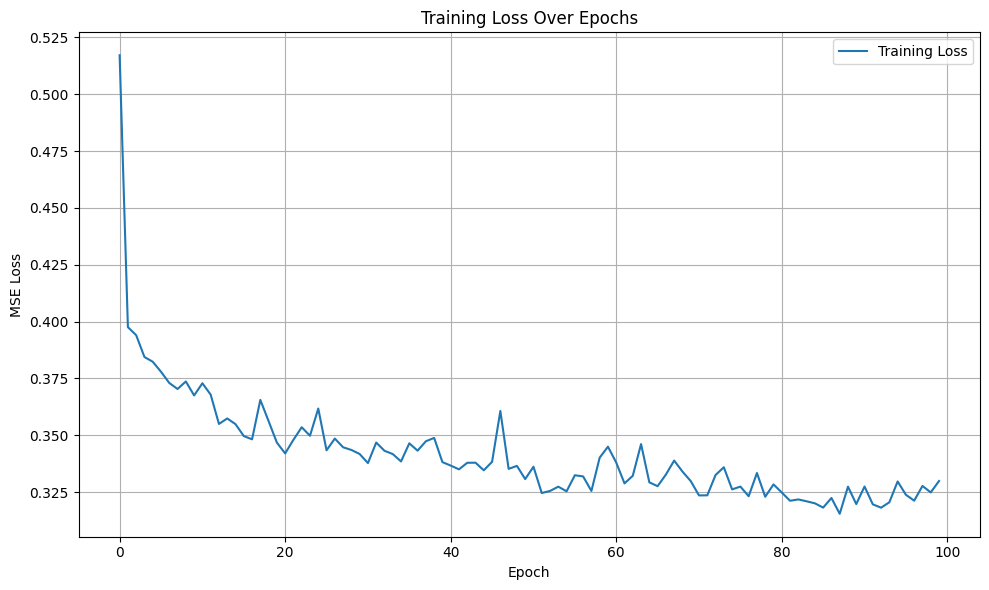

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Bonus: Also compute MAE on train set (optional)
with torch.no_grad():
    y_train_true = []
    y_train_pred = []
    for batch_x, batch_y in train_loader:
        preds = model(batch_x)
        y_train_true.append(batch_y.numpy())
        y_train_pred.append(preds.numpy())

    y_train_true = np.vstack(y_train_true)
    y_train_pred = np.vstack(y_train_pred)

    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

    print(f"Train MAE:  {train_mae:.6f}")
    print(f"Train RMSE: {train_rmse:.6f}")


Train MAE:  0.230315
Train RMSE: 0.558092


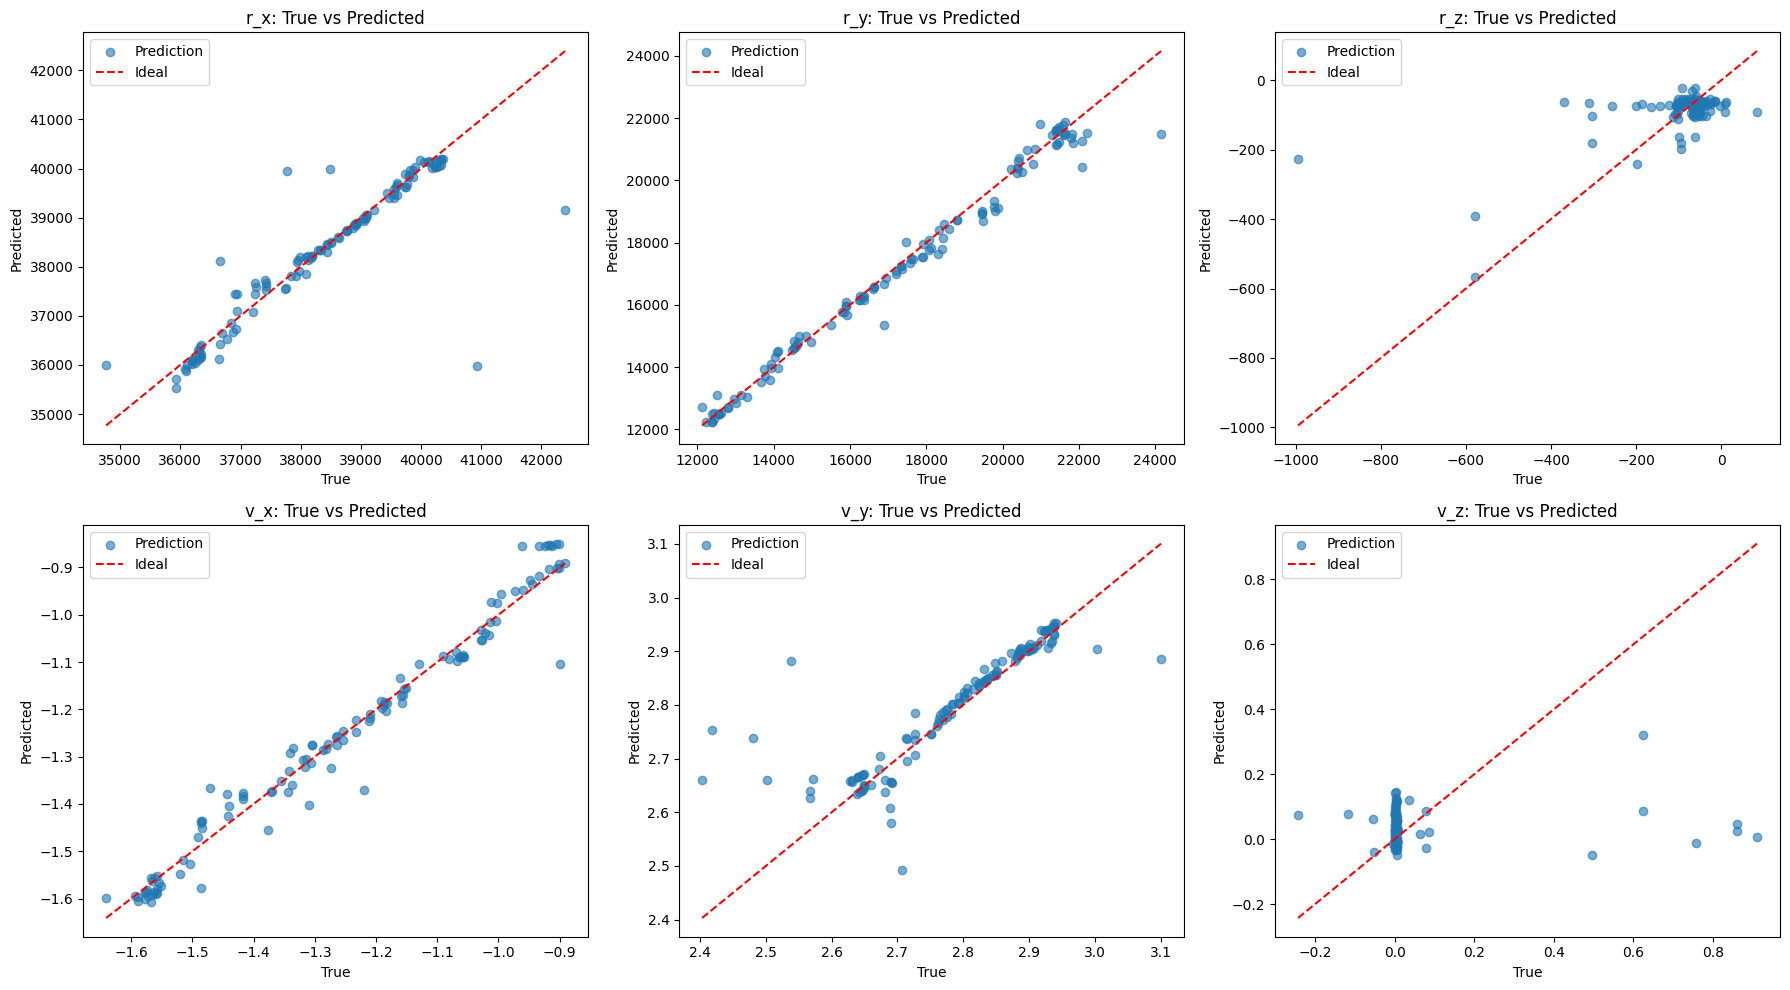

In [ ]:
# Step 5: Extra for ploting
# Code for Plotting (Run locally)
# Once your model is trained, run this code to visualize true vs predicted values:


# Predict on test data
model.eval()
with torch.no_grad():
    preds = model(torch.tensor(X_test, dtype=torch.float32)).numpy()

# Inverse transform to real-world units
y_pred = y_scaler.inverse_transform(preds)
y_true = y_scaler.inverse_transform(y_test)

# Plot
labels = ['r_x', 'r_y', 'r_z', 'v_x', 'v_y', 'v_z']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(6):
    axes[i].scatter(y_true[:, i], y_pred[:, i], alpha=0.6, label='Prediction')
    axes[i].plot([min(y_true[:, i]), max(y_true[:, i])],
                 [min(y_true[:, i]), max(y_true[:, i])], 'r--', label='Ideal')
    axes[i].set_title(f'{labels[i]}: True vs Predicted')
    axes[i].set_xlabel('True')
    axes[i].set_ylabel('Predicted')
    axes[i].legend()

plt.tight_layout()
plt.show()

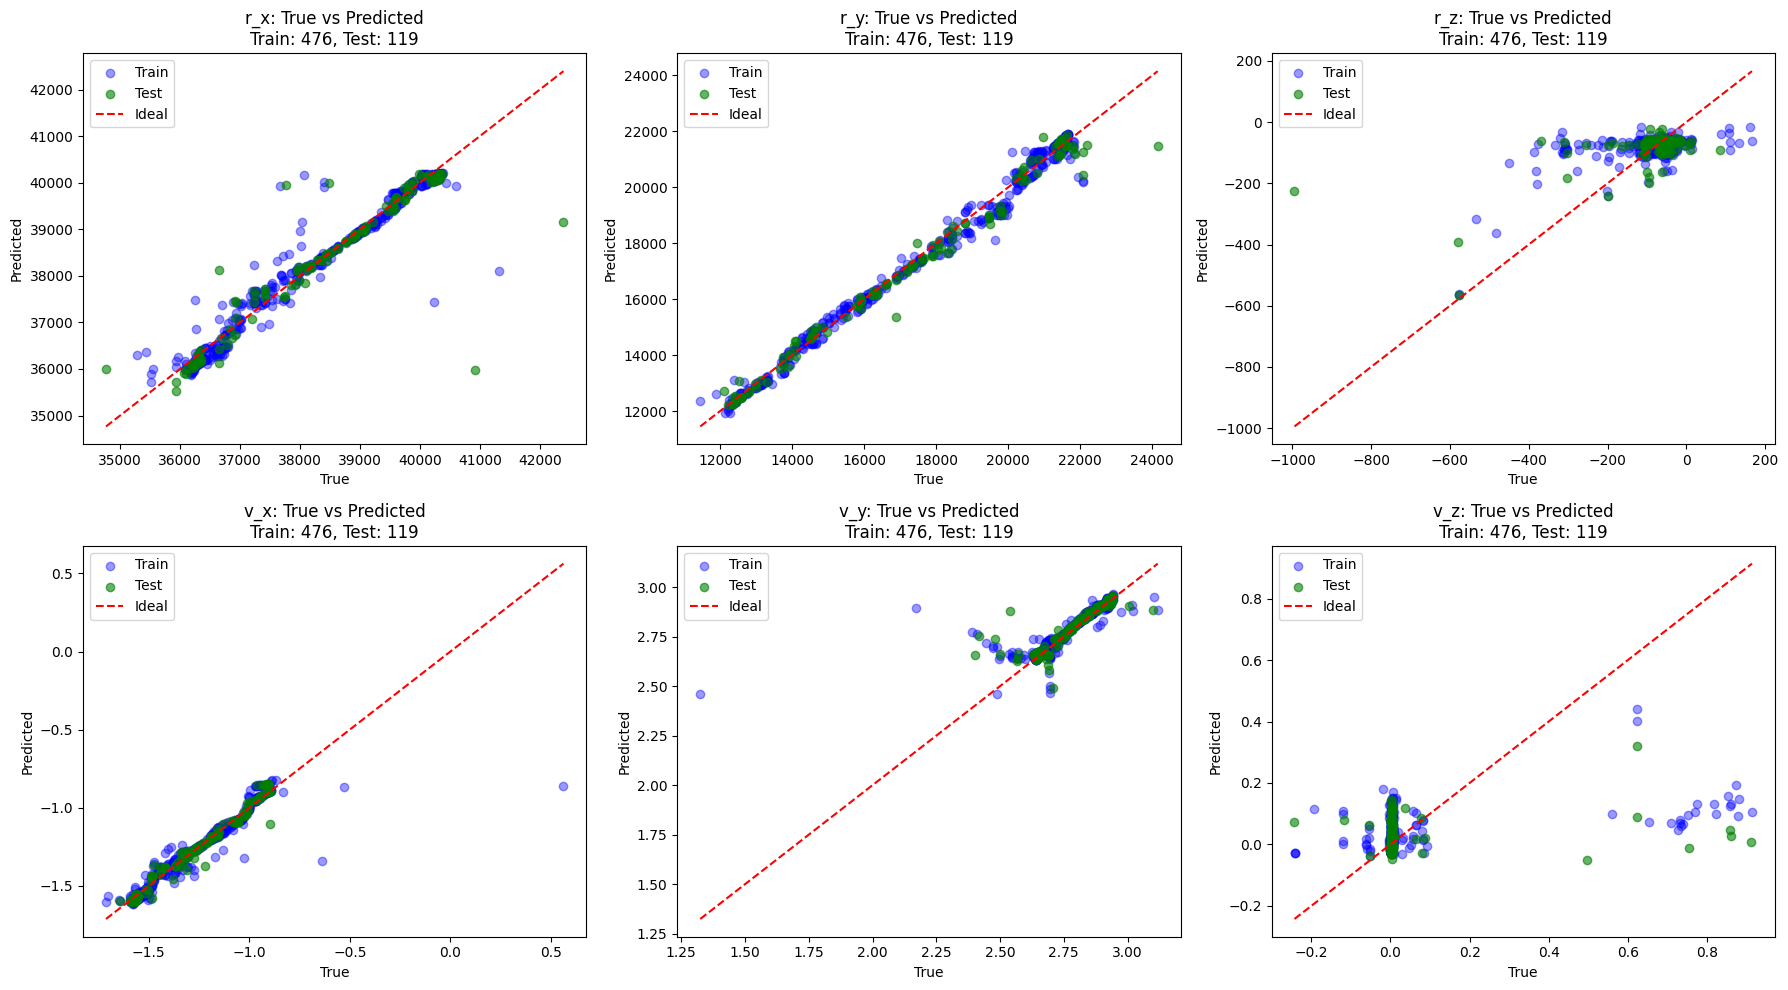

In [ ]:
model.eval()
with torch.no_grad():
    y_pred_test = model(torch.tensor(X_test, dtype=torch.float32)).numpy()
    y_pred_train = model(torch.tensor(X_train, dtype=torch.float32)).numpy()

# Inverse transform
y_pred_test = y_scaler.inverse_transform(y_pred_test)
y_true_test = y_scaler.inverse_transform(y_test)

y_pred_train = y_scaler.inverse_transform(y_pred_train)
y_true_train = y_scaler.inverse_transform(y_train)

# Plotting
labels = ['r_x', 'r_y', 'r_z', 'v_x', 'v_y', 'v_z']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(6):
    # Scatter train and test in different colors
    axes[i].scatter(y_true_train[:, i], y_pred_train[:, i], alpha=0.4, color='blue', label='Train')
    axes[i].scatter(y_true_test[:, i], y_pred_test[:, i], alpha=0.6, color='green', label='Test')

    # Ideal line
    min_val = min(y_true_train[:, i].min(), y_true_test[:, i].min())
    max_val = max(y_true_train[:, i].max(), y_true_test[:, i].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')

    # Title with point counts
    axes[i].set_title(f'{labels[i]}: True vs Predicted\nTrain: {len(y_train)}, Test: {len(y_test)}')
    axes[i].set_xlabel('True')
    axes[i].set_ylabel('Predicted')
    axes[i].legend()

plt.tight_layout()
plt.show()


In [ ]:
# === Compute MAE and RMSE ===
mae = np.mean(np.abs(y_true - y_pred), axis=0)
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))

# === Assume ground truth mean is the denominator for percentage error ===
percent_mae = 100 * mae / np.mean(np.abs(y_true), axis=0)
percent_rmse = 100 * rmse / np.mean(np.abs(y_true), axis=0)

# === Names and Units ===
columns = ['r_x', 'r_y', 'r_z', 'v_x', 'v_y', 'v_z']
units = ['km', 'km', 'km', 'km/s', 'km/s', 'km/s']

# === Table Format (pandas) ===
error_df = pd.DataFrame({
    'MAE': mae,
    'RMSE': rmse
}, index=columns).T

print("\n=== Error Table (MAE and RMSE) ===")
print(error_df.to_string(float_format="{:8.2f}".format))


=== Error Table (MAE and RMSE) ===
          r_x      r_y      r_z      v_x      v_y      v_z
MAE    242.85   274.69    47.22     0.03     0.03     0.08
RMSE   640.21   440.75    95.39     0.04     0.07     0.18


In [ ]:
print("\n=== Detailed Error Breakdown ===")
for i, name in enumerate(columns):
    print(f"{name} MAE:  {mae[i]:10.2f} {units[i]:<5}  ({percent_mae[i]:7.2f}%)")
    print(f"{name} RMSE: {rmse[i]:10.2f} {units[i]:<5}  ({percent_rmse[i]:7.2f}%)")



=== Detailed Error Breakdown ===
r_x MAE:      242.85 km     (   0.63%)
r_x RMSE:     640.21 km     (   1.67%)
r_y MAE:      274.69 km     (   1.59%)
r_y RMSE:     440.75 km     (   2.55%)
r_z MAE:       47.22 km     (  49.66%)
r_z RMSE:      95.39 km     ( 100.32%)
v_x MAE:        0.03 km/s   (   2.16%)
v_x RMSE:       0.04 km/s   (   3.25%)
v_y MAE:        0.03 km/s   (   1.16%)
v_y RMSE:       0.07 km/s   (   2.46%)
v_z MAE:        0.08 km/s   ( 152.00%)
v_z RMSE:       0.18 km/s   ( 343.12%)


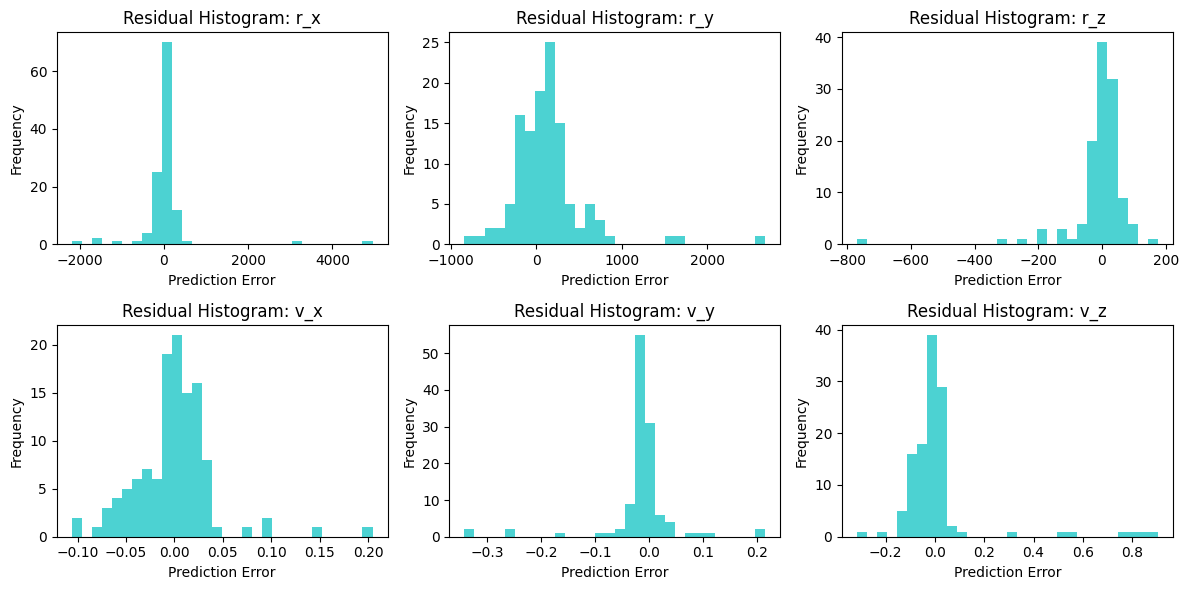

In [ ]:
residuals = y_true - y_pred
plt.figure(figsize=(12, 6))
for i, col in enumerate(columns):
    plt.subplot(2, 3, i+1)
    plt.hist(residuals[:, i], bins=30, alpha=0.7, color='c')
    plt.title(f"Residual Histogram: {col}")
    plt.xlabel("Prediction Error")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [ ]:
print(y_true.shape)

(119, 6)
